In [67]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import normalize
from collections import defaultdict

H5_PATH = "../embeddings/cct_dinov2l_embeddings_v2.h5"
N_BLOCKS = 10
INIT_TRAIN_RATIO = 0.8   # fraction of Block 1 used to initialise prototypes

print("Configuration set.")
print(f"  H5 path        : {H5_PATH}")
print(f"  Blocks         : {N_BLOCKS}")
print(f"  Init train frac: {INIT_TRAIN_RATIO}")

Configuration set.
  H5 path        : ../embeddings/cct_dinov2l_embeddings_v2.h5
  Blocks         : 10
  Init train frac: 0.8


In [55]:
import pandas as pd
import numpy as np
import h5py

with h5py.File(H5_PATH, "r") as hf:
    # 1. Load data
    raw_embeddings = hf["embeddings"][:]
    raw_species    = np.array([s.decode() for s in hf["species"][:]])
    raw_strings    = [t.decode() for t in hf["date_captured"][:]]
    raw_locations  = hf["location"][:]          # ← missing line

    # 2. Convert and Create Mask
    temp_times = pd.to_datetime(raw_strings, errors='coerce')
    mask = temp_times.notna()

    # 3. Apply Mask & Normalize
    embeddings = normalize(raw_embeddings[mask], norm="l2")
    species    = raw_species[mask]
    timestamps = temp_times[mask]
    locations  = raw_locations[mask]            # ← missing line

print(f"Loaded {len(embeddings):,} embeddings after cleaning.")
print(f"Dropped {len(mask) - mask.sum()} rows with invalid timestamps.")

Loaded 107,149 embeddings after cleaning.
Dropped 1 rows with invalid timestamps.


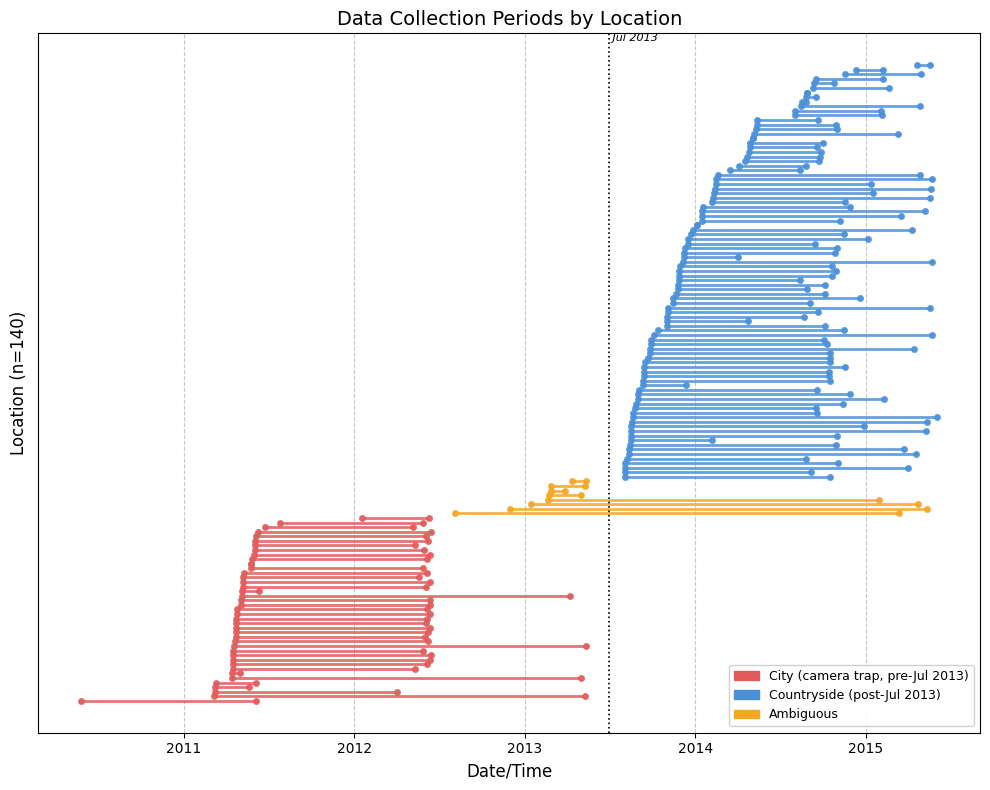

In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# --- Configuration ---
THRESHOLD_DATE = pd.Timestamp('2013-07-01')
AMBIGUOUS_IDS = {71, 118, 47, 80, 135, 61, 85, 41}

# --- Category assignment ---
def assign_category(row):
    loc_id = int(row['location'])
    if loc_id in AMBIGUOUS_IDS:
        return 'ambiguous'
    elif row['min'] < THRESHOLD_DATE:
        return 'city'
    else:
        return 'countryside'

# --- Organize data ---
df = pd.DataFrame({
    'location': locations,
    'timestamp': timestamps
})

timeline_df = df.groupby('location')['timestamp'].agg(['min', 'max']).reset_index()
timeline_df = timeline_df.sort_values(by='min')
timeline_df['category'] = timeline_df.apply(assign_category, axis=1)

# --- Color map ---
COLOR_MAP = {
    'city':        '#E05C5C',  # red
    'countryside': '#4A90D9',  # blue
    'ambiguous':   '#F5A623',  # amber
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 8))

for i, (_, row) in enumerate(timeline_df.iterrows()):
    color = COLOR_MAP[row['category']]
    ax.plot(
        [row['min'], row['max']],
        [i, i],
        color=color,
        marker='o', markersize=4, linewidth=2,
        alpha=0.85
    )

# Threshold line
ax.axvline(THRESHOLD_DATE, color='black', linestyle=':', linewidth=1.2, label='_nolegend_')
ax.text(THRESHOLD_DATE, ax.get_ylim()[1], ' Jul 2013', fontsize=8,
        va='top', color='black', style='italic')

# --- Formatting ---
ax.set_yticks([])
ax.set_ylabel(f'Location (n={len(timeline_df)})', fontsize=12)
ax.set_xlabel('Date/Time', fontsize=12)
ax.set_title('Data Collection Periods by Location', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

# --- Legend ---
legend_handles = [
    mpatches.Patch(color=COLOR_MAP['city'],        label='City (camera trap, pre-Jul 2013)'),
    mpatches.Patch(color=COLOR_MAP['countryside'], label='Countryside (post-Jul 2013)'),
    mpatches.Patch(color=COLOR_MAP['ambiguous'],   label='Ambiguous'),
]
ax.legend(handles=legend_handles, loc='lower right', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('plots/cct_data_collection_periods.pdf', dpi=300, bbox_inches='tight')  # raster fallback
plt.show()

In [20]:
x = [71, 118, 47, 80, 135, 61, 85, 41]
x.sort()
x

[41, 47, 61, 71, 80, 85, 118, 135]

In [21]:
df.location.nunique()

140

In [57]:
# 1. Sort everything chronologically
sort_idx = np.argsort(timestamps)

embeddings = embeddings[sort_idx]
species = species[sort_idx]

# Fix: DatetimeIndex can be indexed directly with the sort_idx array
timestamps = timestamps[sort_idx] 

# 2. Extract Date-only for the "Clever Split" 
# Use .date instead of .dt.date because 'timestamps' is likely a DatetimeIndex
dates_arr = np.array([d.date() for d in timestamps])

print(f"Data sorted. Range: {timestamps.min()} to {timestamps.max()}")
print(f"Total samples after sorting: {len(embeddings):,}")

Data sorted. Range: 2010-05-25 20:32:56 to 2015-06-03 12:07:41
Total samples after sorting: 107,149


In [58]:
def make_date_aware_blocks(dates_arr, n_blocks):
    """
    Partition indices into `n_blocks` roughly equal temporal blocks such that
    no calendar date is split across two blocks.

    Strategy:
      1. Find all unique dates in sorted order.
      2. Assign each date to a target block (0..n_blocks-1) based on cumulative
         sample count, advancing to the next block only at date boundaries.
      3. Return a list of index arrays, one per block.
    """
    N = len(dates_arr)
    target_block_size = N / n_blocks

    # Build a lookup: date → list of row indices (already sorted by time)
    date_to_indices = defaultdict(list)
    for idx, d in enumerate(dates_arr):
        date_to_indices[d].append(idx)

    unique_dates = sorted(date_to_indices.keys())

    blocks   = [[] for _ in range(n_blocks)]
    cur_block = 0
    cumulative = 0

    for d in unique_dates:
        idxs = date_to_indices[d]
        blocks[cur_block].extend(idxs)
        cumulative += len(idxs)
        # Advance to next block when we pass the target boundary,
        # but never exceed n_blocks - 1.
        if cur_block < n_blocks - 1 and cumulative >= (cur_block + 1) * target_block_size:
            cur_block += 1

    return [np.array(b) for b in blocks if len(b) > 0]


blocks = make_date_aware_blocks(dates_arr, N_BLOCKS)

print(f"Created {len(blocks)} temporal blocks (target: {N_BLOCKS})")
print(f"{'Block':>6}  {'Size':>7}  {'Date range'}")
print("-" * 55)
for i, b in enumerate(blocks):
    d_min = dates_arr[b].min()
    d_max = dates_arr[b].max()
    print(f"  {i+1:>4}  {len(b):>7,}  {d_min}  →  {d_max}")

Created 10 temporal blocks (target: 10)
 Block     Size  Date range
-------------------------------------------------------
     1   10,798  2010-05-25  →  2011-06-14
     2   10,685  2011-06-15  →  2011-09-14
     3   10,767  2011-09-15  →  2012-01-03
     4   10,659  2012-01-04  →  2012-03-28
     5   10,710  2012-03-29  →  2012-05-25
     6   10,755  2012-05-26  →  2013-10-23
     7   10,734  2013-10-24  →  2014-01-24
     8   10,769  2014-01-25  →  2014-05-07
     9   10,571  2014-05-08  →  2014-09-07
    10   10,701  2014-09-08  →  2015-06-03


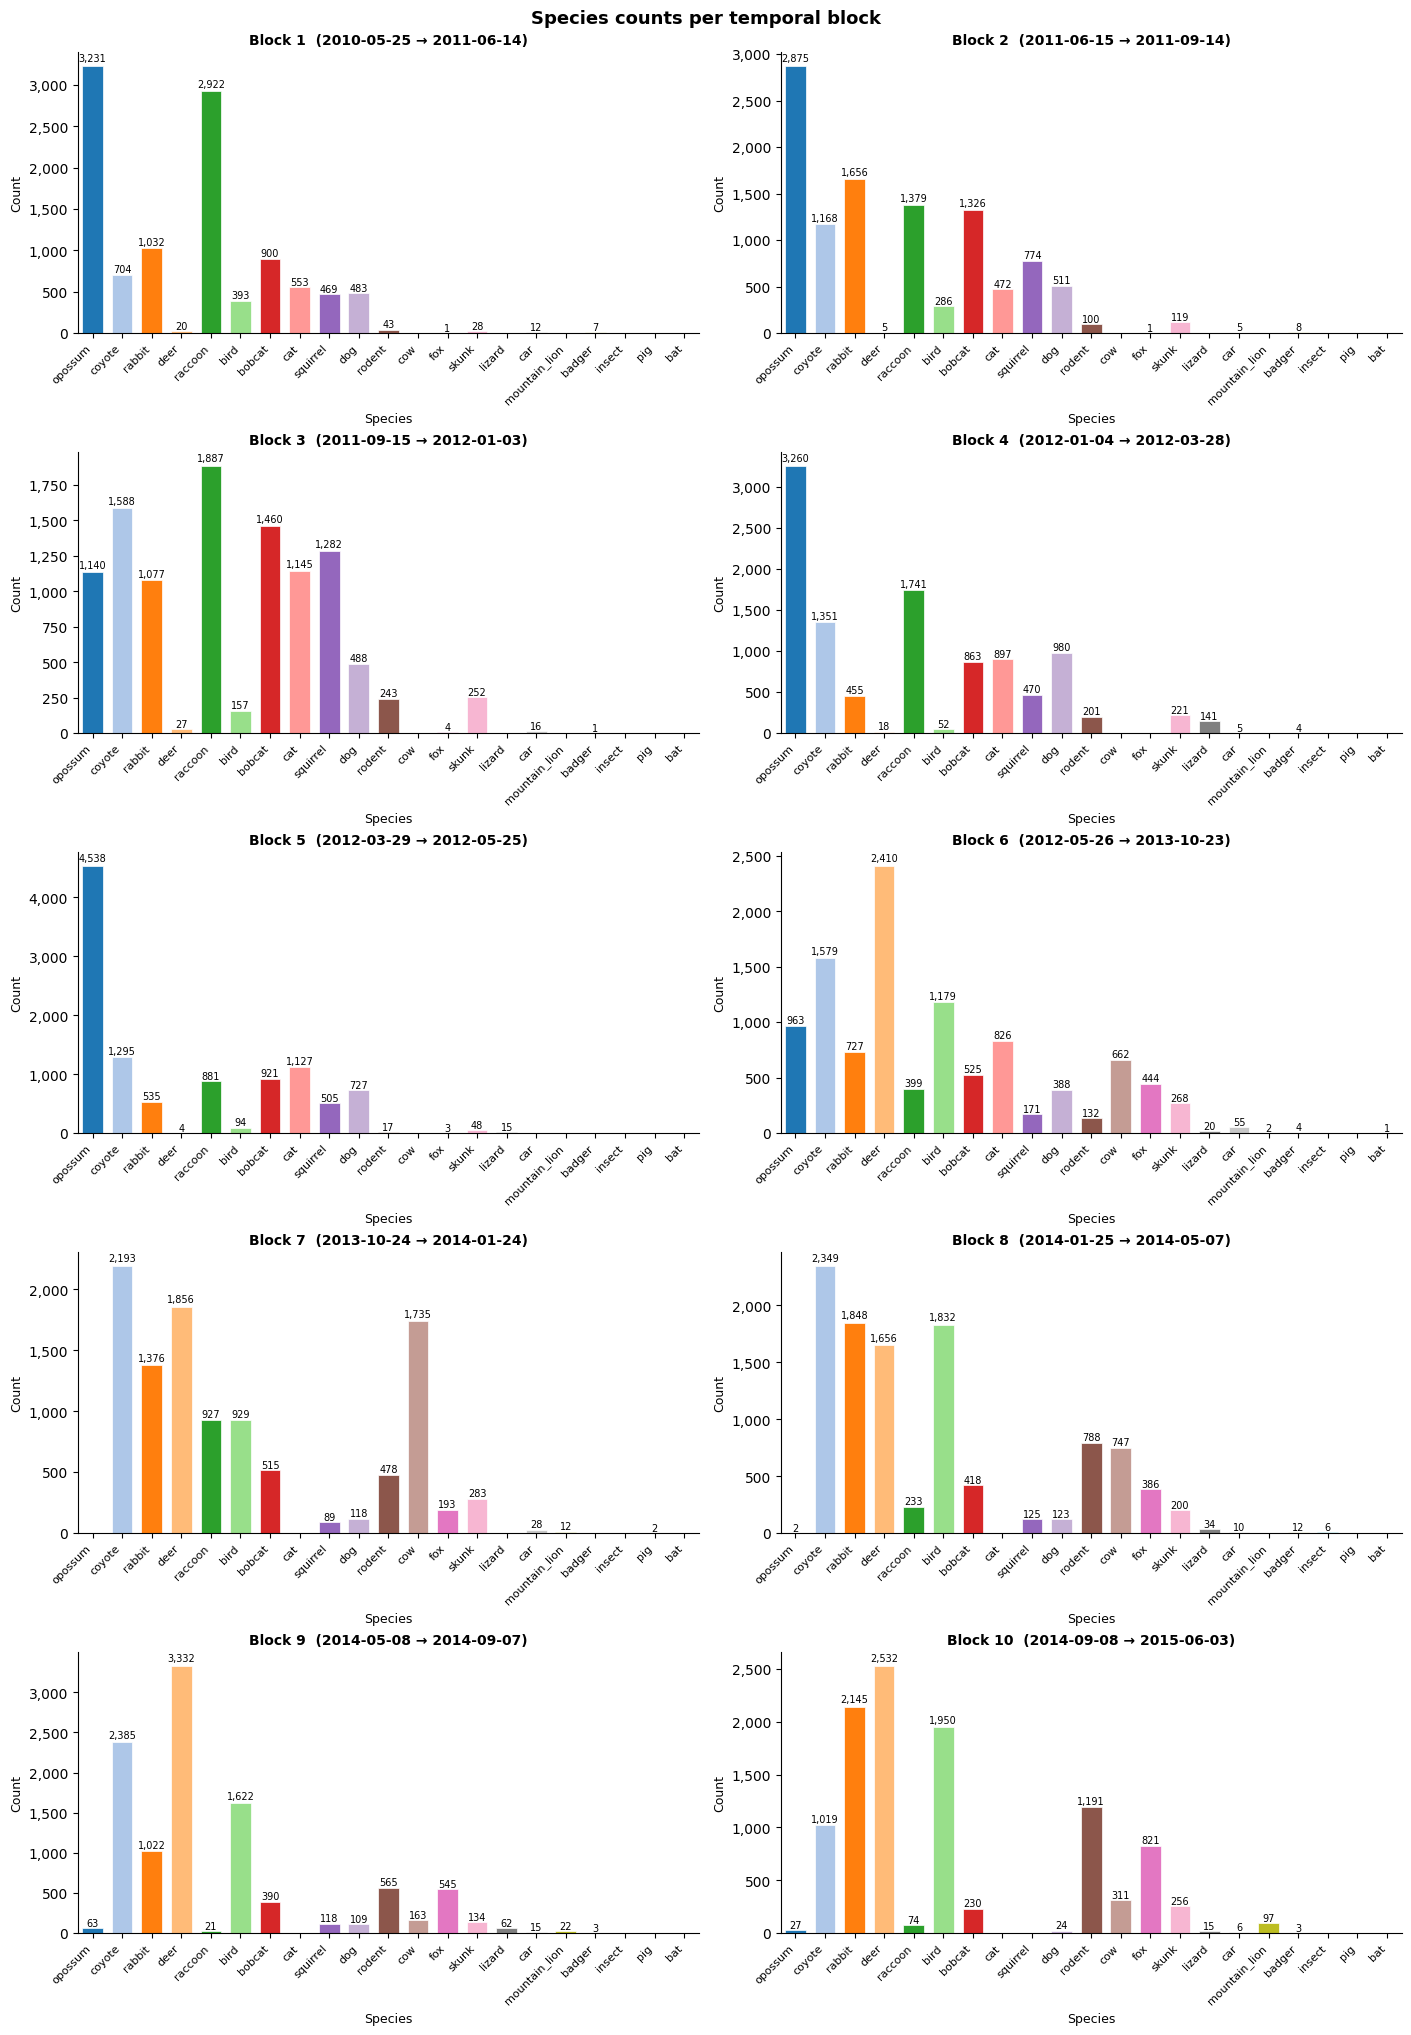

Saved → plots/species_per_block.png


In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
import math

def plot_species_histograms(blocks, species, dates_arr, n_cols=2):
    """
    Plot species count bar charts for each temporal block.
    X-axis species order is fixed (by total count desc) across all blocks.
    Absent species show as 0-height bars.
    """
    n_blocks = len(blocks)
    n_rows   = math.ceil(n_blocks / n_cols)

    # ── Fixed species order: sorted by TOTAL count across all blocks ──────────
    total_counts  = Counter(species)
    ordered_species = [s for s, _ in total_counts.most_common()]   # fixed x-order
    n_species     = len(ordered_species)
    x_positions   = range(n_species)

    # Consistent colour map
    cmap          = plt.cm.get_cmap("tab20", n_species)
    species_color = {s: cmap(i) for i, s in enumerate(ordered_species)}

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(7 * n_cols, 4 * n_rows),
        constrained_layout=True,
        sharey=False   # set True if you want a shared y-scale
    )
    axes = axes.flatten()

    for i, block_idx in enumerate(blocks):
        ax = axes[i]

        block_counts = Counter(species[block_idx])
        # Zero-fill: every species gets a value, even if absent
        vals   = [block_counts.get(s, 0) for s in ordered_species]
        colors = [species_color[s] for s in ordered_species]

        bars = ax.bar(x_positions, vals, color=colors, width=0.7,
                      edgecolor="white", linewidth=0.5)

        d_min = pd.Timestamp(dates_arr[block_idx].min()).strftime("%Y-%m-%d")
        d_max = pd.Timestamp(dates_arr[block_idx].max()).strftime("%Y-%m-%d")
        ax.set_title(f"Block {i+1}  ({d_min} → {d_max})", fontsize=10, fontweight="bold")
        ax.set_xlabel("Species", fontsize=9)
        ax.set_ylabel("Count", fontsize=9)

        ax.set_xticks(list(x_positions))
        ax.set_xticklabels(ordered_species, rotation=45, ha="right", fontsize=8)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

        # Value labels — skip zeros to avoid clutter
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.01,
                    f"{v:,}", ha="center", va="bottom", fontsize=7
                )

        ax.spines[["top", "right"]].set_visible(False)
        ax.set_xlim(-0.5, n_species - 0.5)

    for j in range(n_blocks, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Species counts per temporal block", fontsize=13, fontweight="bold", y=1.01)

    out_path = "plots/species_per_block.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path}")


plot_species_histograms(blocks, species, timestamps, n_cols=2)

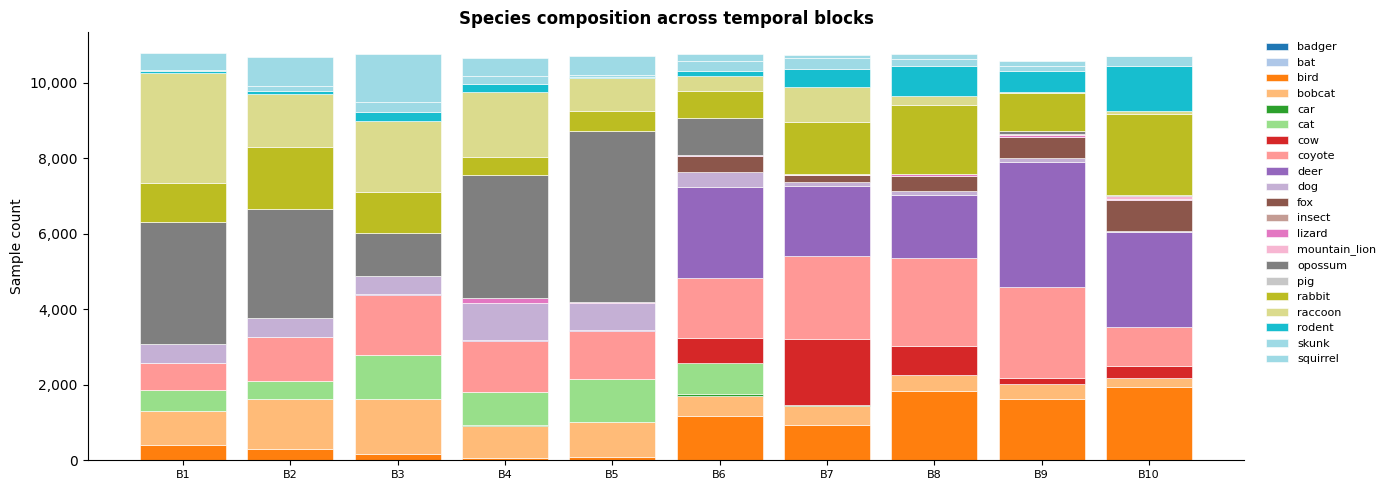

In [25]:
def plot_stacked_overview(blocks, species, dates_arr):
    """Single stacked bar — one bar per block, segments = species."""
    all_species = sorted(set(species))
    cmap = plt.cm.get_cmap("tab20", len(all_species))

    data = {s: [] for s in all_species}
    labels = []
    for i, idx in enumerate(blocks):
        c = Counter(species[idx])
        d_min = pd.Timestamp(dates_arr[idx].min()).strftime("%b %Y")
        labels.append(f"B{i+1}")
        for s in all_species:
            data[s].append(c.get(s, 0))

    fig, ax = plt.subplots(figsize=(14, 5))
    bottoms = [0] * len(blocks)
    for j, s in enumerate(all_species):
        vals = data[s]
        ax.bar(range(len(blocks)), vals, bottom=bottoms,
               label=s, color=cmap(j), edgecolor="white", linewidth=0.4)
        bottoms = [b + v for b, v in zip(bottoms, vals)]

    ax.set_xticks(range(len(blocks)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Sample count")
    ax.set_title("Species composition across temporal blocks", fontweight="bold")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    plt.savefig("plots/species_stacked_overview.pdf", dpi=150, bbox_inches="tight")
    plt.show()

plot_stacked_overview(blocks, species, timestamps)

In [26]:
import copy
import numpy as np
import matplotlib.pyplot as plt

In [62]:
class AdaptiveNCMClassifier:
    def __init__(self):
        self.prototypes = {}
        self.counts = {}

    def _normalized(self, v):
        n = np.linalg.norm(v)
        return v / n if n > 0 else v

    def _compute_dists(self, query_emb):
        if not self.prototypes:
            raise ValueError("Classifier has no prototypes. Fit the model first.")

        species_list = list(self.prototypes.keys())
        query_norm = self._normalized(query_emb)
        protos_norm = np.array(
            [self._normalized(self.prototypes[cls]) for cls in species_list]
        )

        dots = np.clip(protos_norm.dot(query_norm), -1.0, 1.0)
        dists = np.sqrt(np.maximum(0.0, 2.0 - 2.0 * dots))
        return species_list, dists

    def fit(self, g_embs, g_labels):
        for cls in np.unique(g_labels):
            cls_embs = g_embs[g_labels == cls]
            self.prototypes[cls] = np.mean(cls_embs, axis=0)
            self.counts[cls] = len(cls_embs)

    def update(self, new_emb, species):
        n = self.counts.get(species, 0)
        if n == 0:
            self.prototypes[species] = new_emb.copy()
            self.counts[species] = 1
            return

        old_proto = self.prototypes[species]
        new_n = n + 1
        self.prototypes[species] = (old_proto * n + new_emb) / new_n
        self.counts[species] = new_n

    def predict(self, query_emb):
        species_list, dists = self._compute_dists(query_emb)
        nearest_idx = int(np.argmin(dists))
        return species_list[nearest_idx]

    @property
    def known_species(self):
        return set(self.prototypes.keys())


def evaluate_block(clf, embs, lbls):
    species_in_block = sorted(set(lbls))

    sp_correct = {sp: 0 for sp in species_in_block}
    sp_total = {sp: 0 for sp in species_in_block}

    n_correct = 0

    for emb, lbl in zip(embs, lbls):
        pred = clf.predict(emb)
        sp_total[lbl] += 1
        if pred == lbl:
            n_correct += 1
            sp_correct[lbl] += 1

    total = len(lbls)

    per_species_accuracy = {
        sp: (100 * sp_correct[sp] / sp_total[sp] if sp_total[sp] > 0 else float("nan"))
        for sp in species_in_block
    }

    mean_species_accuracy = np.nanmean(list(per_species_accuracy.values()))
    global_accuracy = 100 * n_correct / total if total > 0 else float("nan")

    return {
        "mean_species_accuracy": mean_species_accuracy,
        "global_accuracy": global_accuracy,
        "per_species_accuracy": per_species_accuracy,
        "n_correct_classifications": n_correct,
        "total": total,
    }

def update_classifier_on_block(clf, embs, lbls):
    for emb, lbl in zip(embs, lbls):
        clf.update(emb, lbl)


def run_pipeline(start_clf, blocks, embeddings, species, baseline_row, update_after_eval):
    clf = copy.deepcopy(start_clf)
    results = [baseline_row.copy()]

    for blk_num, blk_idx in enumerate(blocks[1:], start=2):
        blk_idx = np.asarray(blk_idx)
        blk_embs = embeddings[blk_idx]
        blk_lbls = species[blk_idx]

        metrics = evaluate_block(clf, blk_embs, blk_lbls)
        results.append({
            "block": blk_num,
            **metrics,
            "n_known_species": len(clf.known_species),
        })

        if update_after_eval:
            update_classifier_on_block(clf, blk_embs, blk_lbls)

    return results


def print_results(results):
    for row in results:
        print(f"\n{'='*50}")
        print(f"Block {row['block']}")
        print(f"{'='*50}")
        print(f"  Classification Accuracy: {row['mean_species_accuracy']:.1f}%")
        print(f"  Known Species:           {row['n_known_species']}")
        print(f"  Total Samples:           {row['total']}")
        print(f"  Correct Classifications: {row['n_correct_classifications']}")
        #print(f"  New Species Samples:     {row['n_new_species_samples']}")

In [63]:
embeddings = np.asarray(embeddings)
species = np.asarray(species)

clf_block1 = AdaptiveNCMClassifier()

b0_idx = np.asarray(blocks[0])
n_b0 = len(b0_idx)
n_init = max(1, int(INIT_TRAIN_RATIO * n_b0))

init_idx = b0_idx[:n_init]
b0_test_idx = b0_idx[n_init:]

clf_block1.fit(embeddings[init_idx], species[init_idx])

baseline_metrics = evaluate_block(
    clf_block1,
    embeddings[b0_test_idx],
    species[b0_test_idx],
)

baseline_row = {
    "block": 1,
    **baseline_metrics,
    "n_known_species": len(clf_block1.known_species),
}

print(f"Block 1 total samples              : {n_b0:,}")
print(f"Block 1 fit samples                : {n_init:,}")
print(f"Block 1 hold-out samples           : {len(b0_test_idx):,}")
print(f"Initial known species              : {len(clf_block1.known_species)}")
print(f"Block 1 Baseline mean species acc: {baseline_row['mean_species_accuracy']:.3f}")

update_classifier_on_block(clf_block1, embeddings[b0_test_idx], species[b0_test_idx])

clf_start = copy.deepcopy(clf_block1)
print(f"Known species after Block 1        : {len(clf_start.known_species)}")

Block 1 total samples              : 10,798
Block 1 fit samples                : 8,638
Block 1 hold-out samples           : 2,160
Initial known species              : 15
Block 1 Baseline mean species acc: 83.617
Known species after Block 1        : 15


In [64]:
adaptive_results = run_pipeline(
    start_clf=clf_start,
    blocks=blocks,
    embeddings=embeddings,
    species=species,
    baseline_row=baseline_row,
    update_after_eval=True,
)

static_results = run_pipeline(
    start_clf=clf_start,
    blocks=blocks,
    embeddings=embeddings,
    species=species,
    baseline_row=baseline_row,
    update_after_eval=False,
)

# Optional:
print('#'*70)
print("ADAPTIVE PIPELINE")
print_results(adaptive_results)
print('\n')

print('#'*70)
print("STATIC PIPELINE")
print_results(static_results)

######################################################################
ADAPTIVE PIPELINE

Block 1
  Classification Accuracy: 83.6%
  Known Species:           15
  Total Samples:           2160
  Correct Classifications: 1745

Block 2
  Classification Accuracy: 83.5%
  Known Species:           15
  Total Samples:           10685
  Correct Classifications: 8406

Block 3
  Classification Accuracy: 83.9%
  Known Species:           15
  Total Samples:           10767
  Correct Classifications: 8702

Block 4
  Classification Accuracy: 75.7%
  Known Species:           15
  Total Samples:           10659
  Correct Classifications: 7921

Block 5
  Classification Accuracy: 75.8%
  Known Species:           16
  Total Samples:           10710
  Correct Classifications: 7776

Block 6
  Classification Accuracy: 67.6%
  Known Species:           16
  Total Samples:           10755
  Correct Classifications: 8504

Block 7
  Classification Accuracy: 80.0%
  Known Species:           19
  Total Samples:  

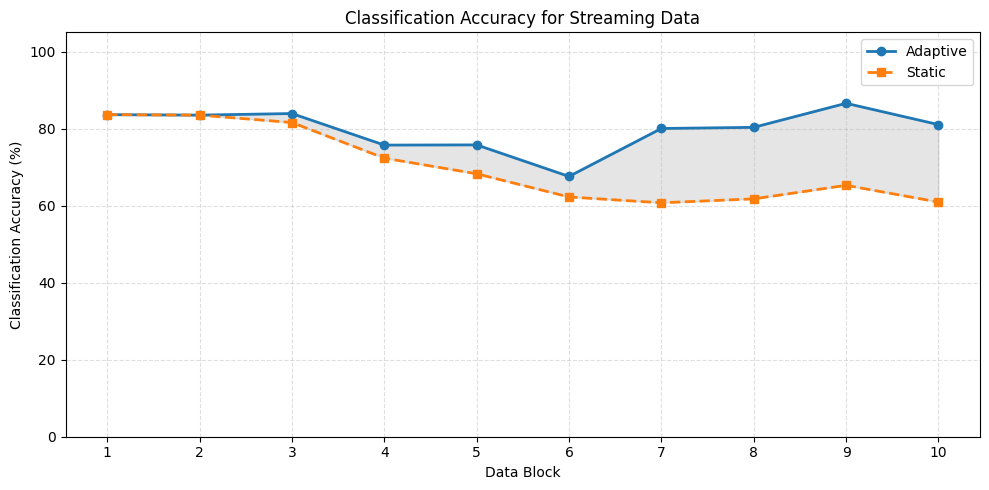

In [66]:
adaptive_blocks = [r["block"] for r in adaptive_results]
adaptive_acc = [r["mean_species_accuracy"] for r in adaptive_results]

static_blocks = [r["block"] for r in static_results]
static_acc = [r["mean_species_accuracy"] for r in static_results]

plt.figure(figsize=(10, 5))

plt.plot(
    adaptive_blocks,
    adaptive_acc,
    marker="o",
    linewidth=2,
    label="Adaptive"
)

plt.plot(
    static_blocks,
    static_acc,
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Static"
)

common_len = min(len(adaptive_blocks), len(static_blocks))
x_common = adaptive_blocks[:common_len]
y_adaptive = np.array(adaptive_acc[:common_len], dtype=float)
y_static = np.array(static_acc[:common_len], dtype=float)

plt.fill_between(
    x_common,
    y_adaptive,
    y_static,
    color="gray",
    alpha=0.2
)

plt.title("Classification Accuracy for Streaming Data")
plt.xlabel("Data Block")
plt.ylabel("Classification Accuracy (%)")

plt.ylim(0, 105)
plt.xticks(adaptive_blocks)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/classification_accuracy_by_block.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
#data enalysis

Evaluating k_factor = 0.00
Evaluating k_factor = 0.25
Evaluating k_factor = 0.50
Evaluating k_factor = 0.75
Evaluating k_factor = 1.00
Evaluating k_factor = 1.25
Evaluating k_factor = 1.50
Evaluating k_factor = 1.75
Evaluating k_factor = 2.00
Evaluating k_factor = 2.25
Evaluating k_factor = 2.50
Evaluating k_factor = 2.75
Evaluating k_factor = 3.00

Best k_factor based on score
  k_factor                    : 0.00
  mean classification accuracy: 81.114
  mean outlier detection rate : 0.907
  score                       : 85.928


,k_factor,mean_classification_accuracy,std_classification_accuracy,mean_outlier_detection_rate,std_outlier_detection_rate,score
0,0.00,81.114153,5.483377,0.907425,0.139724,85.928351
1,0.25,80.678677,5.652022,0.882014,0.132561,84.440016
2,0.50,79.920749,5.865345,0.807365,0.188213,80.328649
3,0.75,79.390021,5.897086,0.625964,0.375864,70.993203
4,1.00,79.186932,5.763785,0.562526,0.359085,67.719766
5,1.25,78.778798,5.210471,0.234960,0.234989,51.137386
6,1.50,79.631803,5.367864,0.124300,0.124726,46.030907
7,1.75,80.375979,5.425740,0.022130,0.024819,41.294479
8,2.00,80.782029,5.431704,0.000000,0.000000,40.391014
9,2.25,81.009258,5.494859,0.000000,0.000000,40.504629


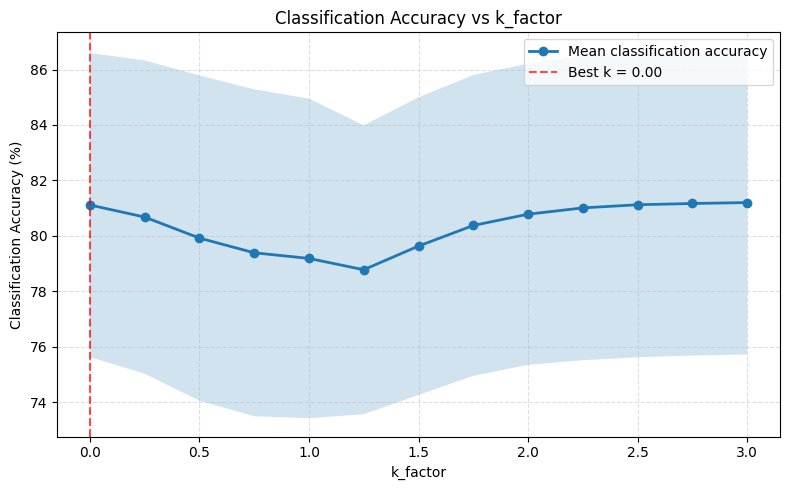

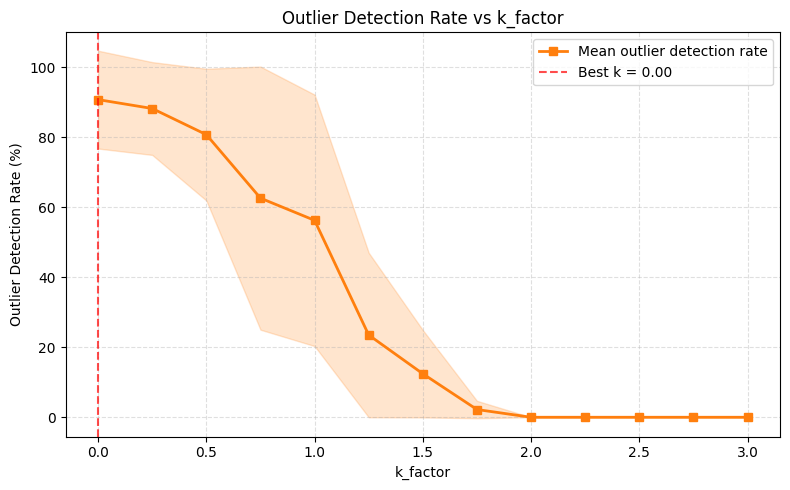

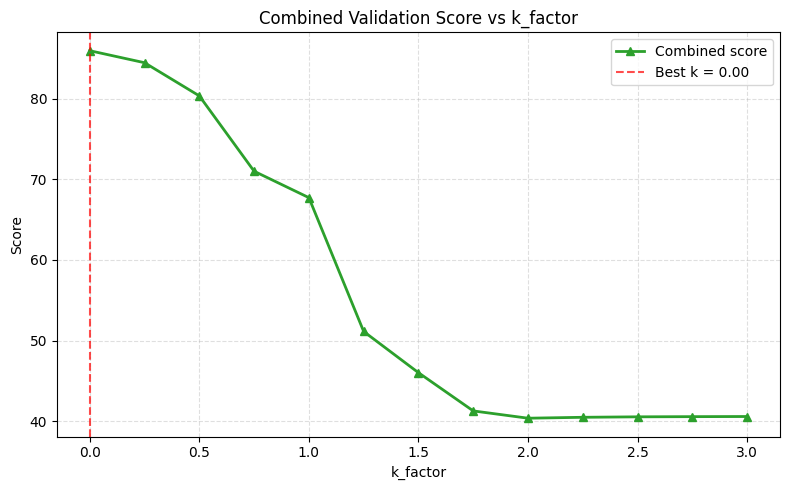

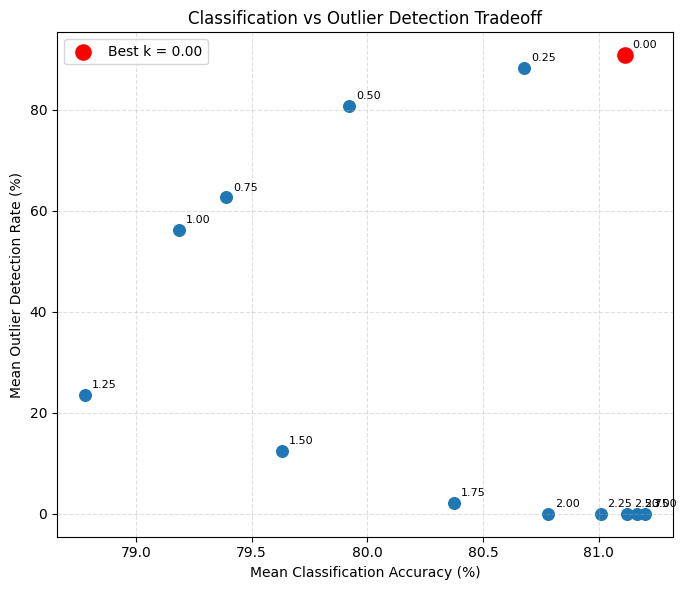

In [38]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

k_values = np.arange(0.0, 3.05, 0.25)
rows = []

for k in k_values:
    print(f"Evaluating k_factor = {k:.2f}")

    clf = AdaptiveNCMClassifier(k_factor=k)
    clf.fit(embeddings[init_idx], species[init_idx])

    baseline_metrics = evaluate_block(
        clf,
        embeddings[b0_test_idx],
        species[b0_test_idx],
    )

    baseline_row = {
        "block": 1,
        **baseline_metrics,
        "n_known_species": len(clf.known_species),
    }

    update_classifier_on_block(clf, embeddings[b0_test_idx], species[b0_test_idx])
    clf_start = copy.deepcopy(clf)

    results = run_pipeline(
        start_clf=clf_start,
        blocks=blocks,
        embeddings=embeddings,
        species=species,
        baseline_row=baseline_row,
        update_after_eval=True,
    )

    cls_acc_by_block = [r["classification_accuracy"] for r in results]
    out_det_by_block = [r["outlier_detection_rate"] for r in results]

    cls_acc_mean = np.nanmean(cls_acc_by_block)
    cls_acc_std = np.nanstd(cls_acc_by_block)

    out_det_mean = np.nanmean(out_det_by_block)
    out_det_std = np.nanstd(out_det_by_block)

    score = 0.5 * cls_acc_mean + 50 * out_det_mean

    rows.append({
        "k_factor": k,
        "mean_classification_accuracy": cls_acc_mean,
        "std_classification_accuracy": cls_acc_std,
        "mean_outlier_detection_rate": out_det_mean,
        "std_outlier_detection_rate": out_det_std,
        "score": score,
    })

results_df = pd.DataFrame(rows).sort_values("k_factor").reset_index(drop=True)

best_idx = results_df["score"].idxmax()
best_row = results_df.loc[best_idx]
best_k = best_row["k_factor"]

print("\nBest k_factor based on score")
print(f"  k_factor                    : {best_k:.2f}")
print(f"  mean classification accuracy: {best_row['mean_classification_accuracy']:.3f}")
print(f"  mean outlier detection rate : {best_row['mean_outlier_detection_rate']:.3f}")
print(f"  score                       : {best_row['score']:.3f}")

display(results_df)

# Optional CSV export
results_df.to_csv("plots/k_factor_sweep_results.csv", index=False)

# ------------------------------------------------------------
# Plot 1: Classification accuracy vs k_factor
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["k_factor"],
    results_df["mean_classification_accuracy"],
    marker="o",
    linewidth=2,
    label="Mean classification accuracy"
)

plt.fill_between(
    results_df["k_factor"],
    results_df["mean_classification_accuracy"] - results_df["std_classification_accuracy"],
    results_df["mean_classification_accuracy"] + results_df["std_classification_accuracy"],
    alpha=0.2
)

plt.axvline(best_k, color="red", linestyle="--", alpha=0.7, label=f"Best k = {best_k:.2f}")

plt.title("Classification Accuracy vs k_factor")
plt.xlabel("k_factor")
plt.ylabel("Classification Accuracy (%)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("plots/k_factor_vs_classification_accuracy.pdf", format="pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Plot 2: Outlier detection rate vs k_factor
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["k_factor"],
    100 * results_df["mean_outlier_detection_rate"],
    marker="s",
    linewidth=2,
    color="tab:orange",
    label="Mean outlier detection rate"
)

plt.fill_between(
    results_df["k_factor"],
    100 * (results_df["mean_outlier_detection_rate"] - results_df["std_outlier_detection_rate"]),
    100 * (results_df["mean_outlier_detection_rate"] + results_df["std_outlier_detection_rate"]),
    alpha=0.2,
    color="tab:orange"
)

plt.axvline(best_k, color="red", linestyle="--", alpha=0.7, label=f"Best k = {best_k:.2f}")

plt.title("Outlier Detection Rate vs k_factor")
plt.xlabel("k_factor")
plt.ylabel("Outlier Detection Rate (%)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("plots/k_factor_vs_outlier_detection_rate.pdf", format="pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Plot 3: Combined score vs k_factor
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["k_factor"],
    results_df["score"],
    marker="^",
    linewidth=2,
    color="tab:green",
    label="Combined score"
)

plt.axvline(best_k, color="red", linestyle="--", alpha=0.7, label=f"Best k = {best_k:.2f}")

plt.title("Combined Validation Score vs k_factor")
plt.xlabel("k_factor")
plt.ylabel("Score")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("plots/k_factor_vs_score.pdf", format="pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Plot 4: Tradeoff scatter
# ------------------------------------------------------------
plt.figure(figsize=(7, 6))

x = results_df["mean_classification_accuracy"]
y = 100 * results_df["mean_outlier_detection_rate"]

plt.scatter(x, y, s=70)

for _, row in results_df.iterrows():
    plt.annotate(
        f"{row['k_factor']:.2f}",
        (row["mean_classification_accuracy"], 100 * row["mean_outlier_detection_rate"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

plt.scatter(
    best_row["mean_classification_accuracy"],
    100 * best_row["mean_outlier_detection_rate"],
    color="red",
    s=120,
    label=f"Best k = {best_k:.2f}"
)

plt.title("Classification vs Outlier Detection Tradeoff")
plt.xlabel("Mean Classification Accuracy (%)")
plt.ylabel("Mean Outlier Detection Rate (%)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("plots/k_factor_tradeoff_scatter.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
import copy
import numpy as np


class FastMajorityVoteKNNBaseline:
    """
    Faster plain kNN baseline with majority vote.

    Speedups vs naive version
    -------------------------
    1. Batch prediction with matrix multiplication
    2. Batched updates instead of repeated np.vstack / np.append
    3. Label encoding to integer ids

    Notes
    -----
    - Uses cosine-based similarity on L2-normalized embeddings
    - No open-set rejection
    - Therefore is_unknown is always False
    """

    def __init__(self, n_neighbors=5, chunk_size=1024):
        self.n_neighbors = n_neighbors
        self.chunk_size = chunk_size

        self.embeddings = None          # shape (N, d), normalized
        self.label_ids = None           # shape (N,)
        self.label_to_id = {}
        self.id_to_label = []

        self._pending_emb_batches = []
        self._pending_label_batches = []

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _normalized(self, v):
        v = np.asarray(v, dtype=float)
        n = np.linalg.norm(v)
        return v / n if n > 0 else v

    def _normalize_rows(self, X):
        X = np.asarray(X, dtype=float)
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return X / norms

    def _get_label_id(self, lbl):
        if lbl not in self.label_to_id:
            self.label_to_id[lbl] = len(self.id_to_label)
            self.id_to_label.append(lbl)
        return self.label_to_id[lbl]

    def _encode_labels(self, labels):
        return np.asarray([self._get_label_id(lbl) for lbl in labels], dtype=np.int32)

    def _flush_pending(self):
        if not self._pending_emb_batches:
            return

        new_embs = np.vstack(self._pending_emb_batches)
        new_ids = np.concatenate(self._pending_label_batches)

        if self.embeddings is None:
            self.embeddings = new_embs
            self.label_ids = new_ids
        else:
            self.embeddings = np.vstack([self.embeddings, new_embs])
            self.label_ids = np.concatenate([self.label_ids, new_ids])

        self._pending_emb_batches.clear()
        self._pending_label_batches.clear()

    def _predict_chunk(self, Q):
        """
        Q: normalized query matrix, shape (B, d)
        returns: preds (object array), is_unknown (bool array)
        """
        sims = np.clip(Q @ self.embeddings.T, -1.0, 1.0)

        k_eff = min(self.n_neighbors, self.embeddings.shape[0])
        nn_idx = np.argpartition(-sims, kth=k_eff - 1, axis=1)[:, :k_eff]

        nn_sims = np.take_along_axis(sims, nn_idx, axis=1)
        nn_label_ids = self.label_ids[nn_idx]

        pred_ids = np.empty(Q.shape[0], dtype=np.int32)

        for i, (row_ids, row_sims) in enumerate(zip(nn_label_ids, nn_sims)):
            counts = np.bincount(row_ids, minlength=len(self.id_to_label))
            max_count = counts.max()
            tied = np.flatnonzero(counts == max_count)

            if len(tied) == 1:
                pred_ids[i] = tied[0]
                continue

            # Tie-break: pick class with highest mean similarity among tied classes
            best_cls = None
            best_key = None
            for cls_id in tied:
                cls_mean_sim = row_sims[row_ids == cls_id].mean()
                key = (-cls_mean_sim, str(self.id_to_label[cls_id]))
                if best_key is None or key < best_key:
                    best_key = key
                    best_cls = cls_id

            pred_ids[i] = best_cls

        preds = np.asarray([self.id_to_label[i] for i in pred_ids], dtype=object)
        is_unknown = np.zeros(Q.shape[0], dtype=bool)
        return preds, is_unknown

    # ------------------------------------------------------------------
    # Fit / Update
    # ------------------------------------------------------------------

    def fit(self, g_embs, g_labels):
        self.label_to_id = {}
        self.id_to_label = []
        self._pending_emb_batches = []
        self._pending_label_batches = []

        self.embeddings = self._normalize_rows(g_embs)
        self.label_ids = self._encode_labels(np.asarray(g_labels, dtype=object))

    def update(self, new_emb, species):
        self.update_many(np.asarray(new_emb)[None, :], np.asarray([species], dtype=object))

    def update_many(self, new_embs, species_list):
        X = self._normalize_rows(new_embs)
        y = self._encode_labels(np.asarray(species_list, dtype=object))
        self._pending_emb_batches.append(X)
        self._pending_label_batches.append(y)

    # ------------------------------------------------------------------
    # Predict
    # ------------------------------------------------------------------

    def predict(self, query_emb):
        preds, is_unknown = self.predict_batch(np.asarray(query_emb)[None, :])
        return preds[0], bool(is_unknown[0])

    def predict_batch(self, query_embs):
        self._flush_pending()

        if self.embeddings is None or len(self.embeddings) == 0:
            raise ValueError("Classifier has not been fit yet.")

        Q = self._normalize_rows(query_embs)

        all_preds = []
        all_unknown = []

        for start in range(0, len(Q), self.chunk_size):
            stop = start + self.chunk_size
            preds, is_unknown = self._predict_chunk(Q[start:stop])
            all_preds.append(preds)
            all_unknown.append(is_unknown)

        return np.concatenate(all_preds), np.concatenate(all_unknown)

    @property
    def known_species(self):
        return set(self.label_to_id.keys())


# ----------------------------------------------------------------------
# Faster evaluation helpers
# ----------------------------------------------------------------------

def evaluate_block_fast(clf, embs, lbls):
    """
    Faster version of evaluate_block using predict_batch() if available.
    Falls back to evaluate_block() otherwise.
    """
    if not hasattr(clf, "predict_batch"):
        return evaluate_block(clf, embs, lbls)

    lbls = np.asarray(lbls, dtype=object)
    known_at_eval = clf.known_species.copy()

    preds, is_unknown = clf.predict_batch(embs)

    sp_correct = {sp: 0 for sp in known_at_eval}
    sp_total = {sp: 0 for sp in known_at_eval}

    correct = 0
    new_species_total = 0
    correctly_flagged_new = 0
    known_but_flagged_unk = 0
    falsely_accepted_new = 0

    for pred, unk, lbl in zip(preds, is_unknown, lbls):
        truly_new = lbl not in known_at_eval

        if truly_new:
            new_species_total += 1
            if unk:
                correctly_flagged_new += 1
            else:
                falsely_accepted_new += 1
        else:
            sp_total[lbl] += 1
            if unk:
                known_but_flagged_unk += 1
            elif pred == lbl:
                correct += 1
                sp_correct[lbl] += 1

    n_known_samples = sum(sp_total.values())

    accuracy = (correct / n_known_samples) * 100 if n_known_samples > 0 else float("nan")
    per_species_acc = {
        sp: (sp_correct[sp] / sp_total[sp] * 100 if sp_total[sp] > 0 else float("nan"))
        for sp in known_at_eval
    }
    discovery_rate = (
        correctly_flagged_new / new_species_total
        if new_species_total > 0
        else float("nan")
    )
    false_rejection_rate = (
        known_but_flagged_unk / n_known_samples
        if n_known_samples > 0
        else 0.0
    )
    false_acceptance_rate = (
        falsely_accepted_new / new_species_total
        if new_species_total > 0
        else 0.0
    )

    return {
        "accuracy": accuracy,
        "per_species_accuracy": per_species_acc,
        "discovery_rate": discovery_rate,
        "false_rejection_rate": false_rejection_rate,
        "false_acceptance_rate": false_acceptance_rate,
        "n_falsely_accepted": falsely_accepted_new,
        "n_new_species_samples": new_species_total,
        "n_known_samples": n_known_samples,
        "total": len(lbls),
    }


def evaluate_block_fixed_set_fast(clf, embs, lbls, eval_species):
    """
    Faster version of evaluate_block_fixed_set using predict_batch() if available.
    Falls back to evaluate_block_fixed_set() otherwise.
    """
    if not hasattr(clf, "predict_batch"):
        return evaluate_block_fixed_set(clf, embs, lbls, eval_species)

    lbls = np.asarray(lbls, dtype=object)
    known_at_eval = clf.known_species.copy()
    fixed_species = set(eval_species)

    preds, is_unknown = clf.predict_batch(embs)

    sp_correct = {sp: 0 for sp in fixed_species}
    sp_total = {sp: 0 for sp in fixed_species}

    correct = 0
    known_but_flagged_unk = 0

    new_species_total = 0
    correctly_flagged_new = 0
    falsely_accepted_new = 0

    ignored_known_nonfixed = 0

    for pred, unk, lbl in zip(preds, is_unknown, lbls):
        if lbl in fixed_species:
            sp_total[lbl] += 1
            if unk:
                known_but_flagged_unk += 1
            elif pred == lbl:
                correct += 1
                sp_correct[lbl] += 1

        elif lbl not in known_at_eval:
            new_species_total += 1
            if unk:
                correctly_flagged_new += 1
            else:
                falsely_accepted_new += 1

        else:
            ignored_known_nonfixed += 1

    n_known_samples = sum(sp_total.values())

    accuracy = (correct / n_known_samples) * 100 if n_known_samples > 0 else float("nan")
    per_species_acc = {
        sp: (sp_correct[sp] / sp_total[sp] * 100 if sp_total[sp] > 0 else float("nan"))
        for sp in fixed_species
    }
    discovery_rate = (
        correctly_flagged_new / new_species_total
        if new_species_total > 0
        else float("nan")
    )
    false_rejection_rate = (
        known_but_flagged_unk / n_known_samples
        if n_known_samples > 0
        else 0.0
    )
    false_acceptance_rate = (
        falsely_accepted_new / new_species_total
        if new_species_total > 0
        else 0.0
    )

    return {
        "accuracy": accuracy,
        "per_species_accuracy": per_species_acc,
        "discovery_rate": discovery_rate,
        "false_rejection_rate": false_rejection_rate,
        "false_acceptance_rate": false_acceptance_rate,
        "n_falsely_accepted": falsely_accepted_new,
        "n_new_species_samples": new_species_total,
        "n_known_samples": n_known_samples,
        "n_ignored_known_nonfixed": ignored_known_nonfixed,
        "total": len(lbls),
    }


def update_classifier_on_block_fast(clf, embs, lbls):
    if hasattr(clf, "update_many"):
        clf.update_many(embs, lbls)
    else:
        for emb, lbl in zip(embs, lbls):
            clf.update(emb, lbl)


def run_pipeline_fast(start_clf, blocks, embeddings, species, baseline_row, update_after_eval):
    clf = copy.deepcopy(start_clf)
    results = [baseline_row.copy()]

    for blk_num, blk_idx in enumerate(blocks[1:], start=2):
        blk_idx = np.asarray(blk_idx)
        blk_embs = embeddings[blk_idx]
        blk_lbls = species[blk_idx]

        metrics = evaluate_block_fast(clf, blk_embs, blk_lbls)
        results.append({
            "block": blk_num,
            **metrics,
            "n_known_species": len(clf.known_species),
        })

        if update_after_eval:
            update_classifier_on_block_fast(clf, blk_embs, blk_lbls)

    return results


def run_pipeline2_fast(start_clf, blocks, embeddings, species, baseline_row, update_after_eval):
    clf = copy.deepcopy(start_clf)
    results = [baseline_row.copy()]

    fixed_eval_species = clf.known_species.copy()

    for blk_num, blk_idx in enumerate(blocks[1:], start=2):
        blk_idx = np.asarray(blk_idx)
        blk_embs = embeddings[blk_idx]
        blk_lbls = species[blk_idx]

        metrics = evaluate_block_fixed_set_fast(
            clf, blk_embs, blk_lbls, eval_species=fixed_eval_species
        )
        results.append({
            "block": blk_num,
            **metrics,
            "n_known_species": len(clf.known_species),
        })

        if update_after_eval:
            update_classifier_on_block_fast(clf, blk_embs, blk_lbls)

    return results


# ----------------------------------------------------------------------
# Separate fast kNN experiment
# ----------------------------------------------------------------------

def run_fast_knn_majority_vote_experiment(
    blocks,
    embeddings,
    species,
    n_neighbors=5,
    chunk_size=1024,
    update_after_eval=True,
    use_fixed_set=False,
):
    embeddings = np.asarray(embeddings)
    species = np.asarray(species, dtype=object)

    b1 = np.asarray(blocks[0])

    start_clf = FastMajorityVoteKNNBaseline(
        n_neighbors=n_neighbors,
        chunk_size=chunk_size,
    )
    start_clf.fit(embeddings[b1], species[b1])

    baseline_metrics = evaluate_block_fast(start_clf, embeddings[b1], species[b1])
    baseline_row = {
        "block": 1,
        **baseline_metrics,
        "n_known_species": len(start_clf.known_species),
    }

    if use_fixed_set:
        results = run_pipeline2_fast(
            start_clf=start_clf,
            blocks=blocks,
            embeddings=embeddings,
            species=species,
            baseline_row=baseline_row,
            update_after_eval=update_after_eval,
        )
    else:
        results = run_pipeline_fast(
            start_clf=start_clf,
            blocks=blocks,
            embeddings=embeddings,
            species=species,
            baseline_row=baseline_row,
            update_after_eval=update_after_eval,
        )

    return start_clf, results


In [ ]:
import matplotlib.pyplot as plt


def plot_with_vs_without_adaptation(
    results_with_adaptation,
    results_without_adaptation,
    model_name="Model",
    figsize=(8, 5),
):
    blocks_with = [row["block"] for row in results_with_adaptation]
    accs_with = [row["accuracy"] for row in results_with_adaptation]

    blocks_without = [row["block"] for row in results_without_adaptation]
    accs_without = [row["accuracy"] for row in results_without_adaptation]

    plt.figure(figsize=figsize)
    plt.plot(blocks_with, accs_with, marker="o", linewidth=2, label=f"{model_name} - with adaptation")
    plt.plot(blocks_without, accs_without, marker="s", linewidth=2, linestyle="--", label=f"{model_name} - without adaptation")

    plt.xlabel("Temporal Block")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{model_name}: Accuracy With vs Without Adaptation")
    plt.xticks(sorted(set(blocks_with) | set(blocks_without)))
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
knn_clf_with, knn_results_with = run_fast_knn_majority_vote_experiment(
    blocks=blocks,
    embeddings=embeddings,
    species=species,
    n_neighbors=5,
    chunk_size=1024,
    update_after_eval=True,
    use_fixed_set=True,
)

knn_clf_without, knn_results_without = run_fast_knn_majority_vote_experiment(
    blocks=blocks,
    embeddings=embeddings,
    species=species,
    n_neighbors=5,
    chunk_size=1024,
    update_after_eval=False,
    use_fixed_set=True,
)

plot_with_vs_without_adaptation(
    knn_results_with,
    knn_results_without,
    model_name="kNN Baseline",
)